# Email Spam Detection

This notebook walks through building a **high-performing email spam classifier** from scratch using classical ML techniques. We'll cover:

1. **Loading & inspecting** the dataset
2. **Exploratory Data Analysis (EDA)** — understanding class balance, text length distributions
3. **Text preprocessing** — cleaning raw email text into a normalized form
4. **Feature extraction** with TF-IDF (turning text into numbers)
5. **Model training & comparison** — Logistic Regression, SGD, Naive Bayes
6. **Evaluation** — confusion matrix, ROC/PR curves, cross-validation
7. **Interpretation** — which words signal spam vs. ham?
8. **Saving & using** the trained model

## 1. Setup & Load Data

Our dataset is a CSV with two columns:
- **`label`**: `1` = spam, `0` = ham (not spam)
- **`text`**: the raw email content

At ~83K emails, this is a reasonably large dataset for text classification.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline

%matplotlib inline
sns.set_style("whitegrid")
SEED = 42

In [21]:
import zipfile, os

# Unzip data if needed
if not os.path.exists("data/data.csv"):
    with zipfile.ZipFile("data/data.zip", "r") as z:
        z.extractall(".")
    print("Extracted data/data.csv from zip.")

df = pd.read_csv("data/data.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (83448, 2)


,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [22]:
df.info()
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Duplicate texts: {df['text'].duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   83448 non-null  int64 
 1   text    83448 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.3+ MB

Null values:
label    0
text     0
dtype: int64

Duplicate rows: 0
Duplicate texts: 2


In [23]:
# Drop the 2 exact-duplicate texts
df = df.drop_duplicates(subset="text", keep="first").reset_index(drop=True)
print(f"After dedup: {df.shape}")

After dedup: (83446, 2)


## 2. Exploratory Data Analysis

Before building any model, we need to understand the data. Key questions:
- Is the dataset **balanced**? (roughly equal spam vs. ham)
- Do spam and ham emails differ in **length**?
- What do the raw emails **look like**?

In [24]:
print("Class distribution:")
print(df["label"].value_counts())
print(f"\nSpam %: {df['label'].mean():.2%}")
print(f"Ham %:  {1 - df['label'].mean():.2%}")

Class distribution:
label
1    43908
0    39538
Name: count, dtype: int64

Spam %: 52.62%
Ham %:  47.38%


The dataset is nearly balanced (~53% spam, ~47% ham), so we don't need to worry about class imbalance techniques like oversampling or class weights.

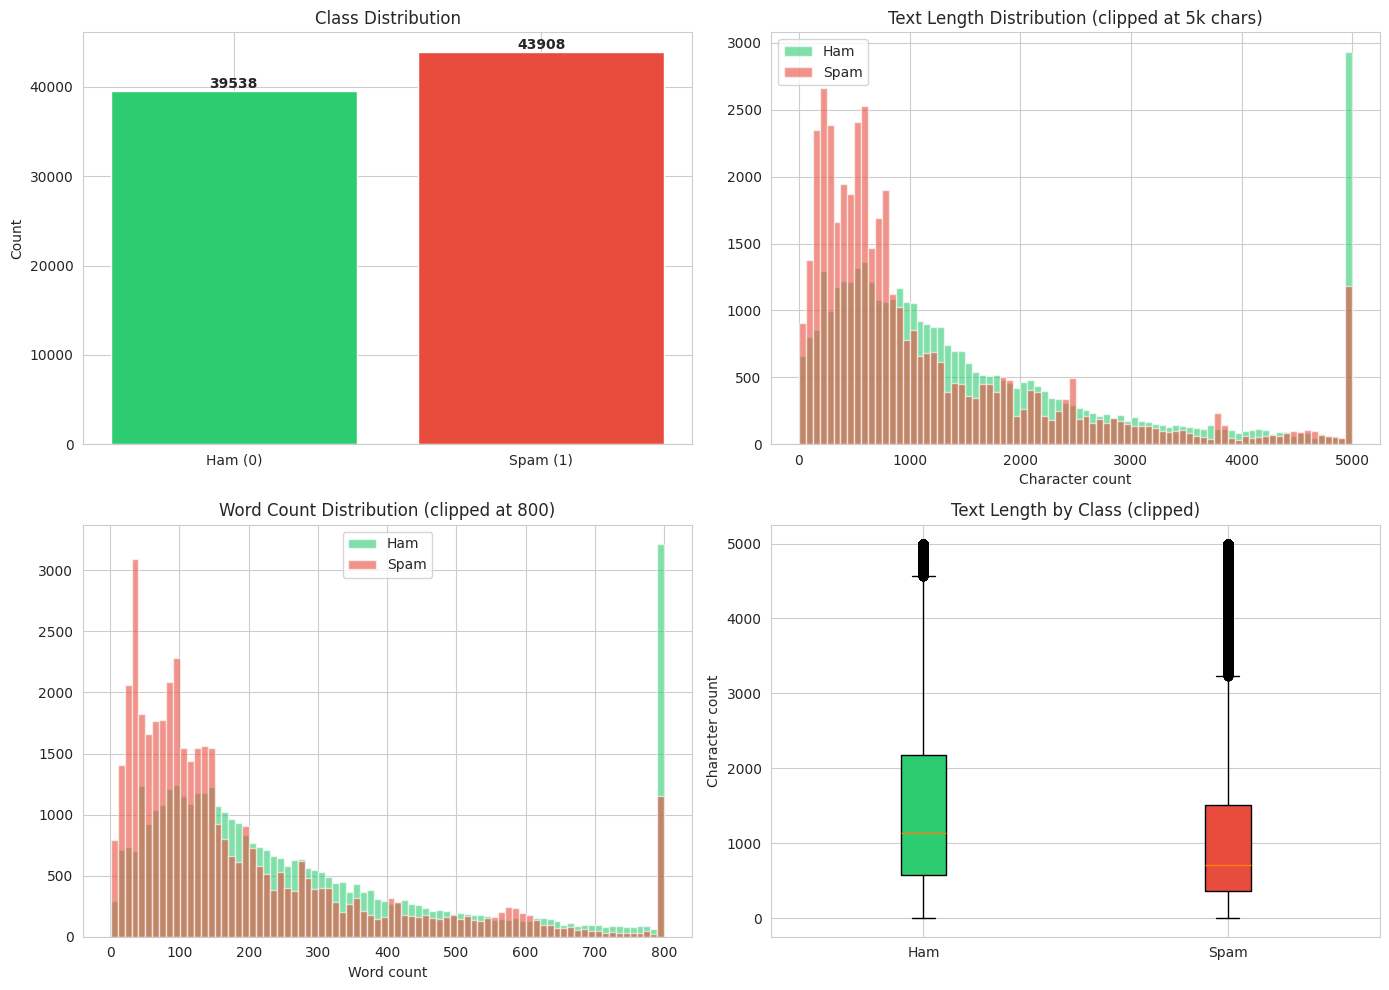

In [25]:
df["text_len"] = df["text"].astype(str).str.len()
df["word_count"] = df["text"].astype(str).str.split().apply(len)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Class distribution
ax = axes[0, 0]
counts = df["label"].value_counts().sort_index()
ax.bar(["Ham (0)", "Spam (1)"], counts.values, color=["#2ecc71", "#e74c3c"])
ax.set_title("Class Distribution")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 300, str(v), ha="center", fontweight="bold")

# Text length distribution
ax = axes[0, 1]
for label, color, name in [(0, "#2ecc71", "Ham"), (1, "#e74c3c", "Spam")]:
    subset = df[df["label"] == label]["text_len"].clip(upper=5000)
    ax.hist(subset, bins=80, alpha=0.6, color=color, label=name)
ax.set_title("Text Length Distribution (clipped at 5k chars)")
ax.set_xlabel("Character count")
ax.legend()

# Word count distribution
ax = axes[1, 0]
for label, color, name in [(0, "#2ecc71", "Ham"), (1, "#e74c3c", "Spam")]:
    subset = df[df["label"] == label]["word_count"].clip(upper=800)
    ax.hist(subset, bins=80, alpha=0.6, color=color, label=name)
ax.set_title("Word Count Distribution (clipped at 800)")
ax.set_xlabel("Word count")
ax.legend()

# Box plot
ax = axes[1, 1]
data_to_plot = [
    df[df["label"] == 0]["text_len"].clip(upper=5000),
    df[df["label"] == 1]["text_len"].clip(upper=5000),
]
bp = ax.boxplot(data_to_plot, tick_labels=["Ham", "Spam"], patch_artist=True)
bp["boxes"][0].set_facecolor("#2ecc71")
bp["boxes"][1].set_facecolor("#e74c3c")
ax.set_title("Text Length by Class (clipped)")
ax.set_ylabel("Character count")

plt.tight_layout()
plt.show()

In [26]:
print("Text length stats by class:")
df.groupby("label")[["text_len", "word_count"]].describe().round(1)

Text length stats by class:


text_len                                                        \
         count    mean     std  min    25%     50%     75%       max   
label                                                                  
0      39538.0  2121.7  5666.1  1.0  579.0  1139.0  2174.0  598705.0   
1      43908.0  1249.9  1978.7  1.0  360.0   704.0  1510.0  144087.0   

      word_count                                                    
           count   mean    std  min    25%    50%    75%       max  
label                                                               
0        39538.0  365.1  984.3  1.0  106.0  200.0  378.0  101984.0  
1        43908.0  208.8  338.3  1.0   61.0  122.0  249.0   25393.0

**Key EDA takeaways:**
- Ham emails tend to be **longer** (median ~1,139 chars) than spam (median ~704 chars). This makes intuitive sense — legitimate emails often contain detailed content, while spam tends to be short and punchy.
- Both distributions are **right-skewed** with some very long outliers, so we'll want our model to be robust to varying lengths.
- The dataset is well-balanced, so **accuracy** is a reasonable metric (though we'll track F1 and AUC too).

In [27]:
# Let's peek at a few examples from each class
print("=" * 60)
print("SPAM EXAMPLES")
print("=" * 60)
for text in df[df["label"] == 1]["text"].sample(3, random_state=SEED).values:
    print(text[:200], "...\n")

print("=" * 60)
print("HAM EXAMPLES")
print("=" * 60)
for text in df[df["label"] == 0]["text"].sample(3, random_state=SEED).values:
    print(text[:200], "...\n")

SPAM EXAMPLES
wireless optical
3 - button scroll mouse
limited
stocks !
$ 16 . 90
cordless freedom with optical precision ! this
logitech cordless optical mouse works on any surface with
optical sensors that provid ...

anatrim escapenumber the latest and most exciting product for weighty people is escapenumber now available escapenumber as seen on oprah did you realize that redundant body kilograms kill a lot of peo ...

continuity deadlock apex neoclassic economy
find your medication instantly !
everything you want ! fast and cheap !
all your needs in one shop !
stop receiving promotional material now
diversion blomb ...

HAM EXAMPLES
umaru yar'adua candidate of nigeria's ruling pdp has won the country's controversial presidential election the electoral commission says for more details http www bbc co uk news this e mail is never s ...

on tue jun escapenumber escapenumber at escapenumber escapenumber escapenumberpm escapenumber jra samba org wrote max params return is complete ficti

## 3. Text Preprocessing

Raw text is messy. Before feeding it to a model, we normalize it:

1. **Lowercase** everything — "FREE" and "free" should be treated the same
2. **Replace URLs** with a `URL` token — the *presence* of a URL matters more than the specific URL
3. **Replace emails** with an `EMAIL` token — same reasoning
4. **Replace numbers** with a `NUM` token — specific numbers usually aren't informative
5. **Handle dataset-specific placeholders** — this dataset uses `escapenumber` and `escapelong`
6. **Remove non-alphabetic characters** and collapse whitespace

This reduces the vocabulary size dramatically while preserving the meaningful signal.

In [28]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " URL ", text)          # URLs -> token
    text = re.sub(r"\b[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}\b", " EMAIL ", text)
    text = re.sub(r"escapenumber", " NUM ", text)               # dataset-specific
    text = re.sub(r"escapelong", " ", text)                     # dataset-specific
    text = re.sub(r"\d+", " NUM ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Show before/after
sample = df["text"].iloc[1]
print("BEFORE:")
print(sample[:300])
print("\nAFTER:")
print(clean_text(sample)[:300])

BEFORE:
wulvob get your medircations online qnb ikud viagra escapenumber escapenumber levitra escapenumber escapenumber cialis escapenumber escapenumber imitrex escapenumber escapenumber flonax escapenumber escapenumber ultram escapenumber escapenumber vioxx escapenumber escapenumber ambien escapenumber esc

AFTER:
wulvob get your medircations online qnb ikud viagra levitra cialis imitrex flonax ultram vioxx ambien valium xannax soma meridia cysfrt have you ever stopped to wonder how much an average man pays for his mediecines ap painkillers drugs to improve the quality of life weight reducing tablets and many


In [29]:
df["clean_text"] = df["text"].apply(clean_text)
print("Preprocessing complete.")

Preprocessing complete.


## 4. Train/Test Split

We hold out 15% of the data for testing. **Stratified** splitting ensures the train and test sets have the same spam/ham ratio as the full dataset. This prevents the model from being evaluated on a skewed subset.

We **never** look at the test set during training — it simulates unseen real-world data.

In [30]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train spam rate: {y_train.mean():.2%}")
print(f"Test spam rate:  {y_test.mean():.2%}")

Train: 70,929  |  Test: 12,517
Train spam rate: 52.62%
Test spam rate:  52.62%


## 5. Feature Extraction with TF-IDF

ML models need **numbers**, not text. **TF-IDF** (Term Frequency-Inverse Document Frequency) converts each email into a sparse vector where each dimension represents a word (or bigram):

- **TF** (Term Frequency): how often a word appears in *this* email
- **IDF** (Inverse Document Frequency): penalizes words that appear in *many* emails (e.g., "the", "and") since they're not distinctive
- **TF-IDF = TF x IDF**: words that are frequent in a document but rare overall get high scores

Key hyperparameters:
- `ngram_range=(1, 2)`: capture single words *and* two-word phrases ("click here", "free money")
- `max_features=120,000`: keep the top 120K features by frequency
- `min_df=3`: ignore words that appear in fewer than 3 emails (too rare to generalize)
- `max_df=0.95`: ignore words that appear in >95% of emails (too common to be useful)
- `sublinear_tf=True`: apply log scaling to TF — dampens the effect of very frequent words

In [31]:
tfidf = TfidfVectorizer(
    max_features=120_000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents="unicode",
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"Train matrix shape: {X_train_tfidf.shape}  (emails x features)")
print(f"Sparsity: {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4%}")

Vocabulary size: 120,000
Train matrix shape: (70929, 120000)  (emails x features)
Sparsity: 99.8217%


The matrix is extremely sparse (~99.9%+ zeros) — most emails only use a tiny fraction of the total vocabulary. Scikit-learn handles this efficiently with sparse matrix representations.

## 6. Model Training & Comparison

We train three different classifiers and compare their performance:

| Model | How it works | Why try it? |
|-------|-------------|-------------|
| **Logistic Regression** | Learns a weight for each word, sums them up, applies sigmoid to get a probability | Strong baseline for text; interpretable weights |
| **SGD Classifier** | Same idea as LR but trained with Stochastic Gradient Descent — processes one sample at a time | Scales better to large datasets; often faster |
| **Multinomial Naive Bayes** | Assumes words are independent given the class; uses Bayes' theorem | Classic spam filter; very fast; surprisingly effective |

We evaluate with three metrics:
- **Accuracy**: % of correct predictions (works well here since classes are balanced)
- **F1 Score**: harmonic mean of precision and recall — balances false positives and false negatives
- **ROC AUC**: measures how well the model separates classes across all thresholds (1.0 = perfect)

In [32]:
models = {
    "Logistic Regression": LogisticRegression(
        C=1.0, max_iter=1000, solver="lbfgs", random_state=SEED, n_jobs=-1
    ),
    "SGD (log loss)": SGDClassifier(
        loss="modified_huber", alpha=1e-5, max_iter=1000,
        random_state=SEED, n_jobs=-1
    ),
    "Multinomial NB": MultinomialNB(alpha=0.05),
}

results = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test_tfidf)
    y_proba = (
        model.predict_proba(X_test_tfidf)[:, 1]
        if hasattr(model, "predict_proba")
        else model.decision_function(X_test_tfidf)
    )

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        "accuracy": acc, "f1": f1, "roc_auc": auc,
        "train_time": train_time, "y_pred": y_pred, "y_proba": y_proba,
    }
    print(f"{name:25s}  acc={acc:.4f}  f1={f1:.4f}  auc={auc:.4f}  ({train_time:.1f}s)")

# Summary table
pd.DataFrame({k: {m: f"{v:.4f}" for m, v in v_dict.items() if m != "y_pred" and m != "y_proba"}
              for k, v_dict in results.items()}).T

Logistic Regression        acc=0.9884  f1=0.9891  auc=0.9986  (3.5s)
SGD (log loss)             acc=0.9934  f1=0.9938  auc=0.9988  (0.6s)
Multinomial NB             acc=0.9760  f1=0.9768  auc=0.9978  (0.1s)


,accuracy,f1,roc_auc,train_time
Logistic Regression,0.9884,0.9891,0.9986,3.4741
SGD (log loss),0.9934,0.9938,0.9988,0.5657
Multinomial NB,0.9760,0.9768,0.9978,0.1166


## 7. Detailed Evaluation of Best Model

We select the model with the highest **F1 score** and do a deeper evaluation.

In [33]:
best_name = max(results, key=lambda k: results[k]["f1"])
best = results[best_name]
print(f"Best model: {best_name}\n")
print(classification_report(y_test, best["y_pred"], target_names=["Ham", "Spam"]))

Best model: SGD (log loss)



              precision    recall  f1-score   support

         Ham       1.00      0.99      0.99      5931
        Spam       0.99      1.00      0.99      6586

    accuracy                           0.99     12517
   macro avg       0.99      0.99      0.99     12517
weighted avg       0.99      0.99      0.99     12517



### Cross-Validation

A single train/test split can be lucky or unlucky. **5-fold cross-validation** gives a more robust estimate: we split the training data into 5 folds, train on 4, test on 1, and rotate. The mean and standard deviation tell us how stable the model is.

In [34]:
cv_scores = cross_val_score(
    models[best_name], X_train_tfidf, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring="f1", n_jobs=-1
)
print(f"5-Fold CV F1 scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

5-Fold CV F1 scores: [0.9923 0.9914 0.9926 0.9905 0.991 ]
Mean: 0.9915 +/- 0.0008


### Evaluation Plots

Three key visualizations:

1. **Confusion Matrix** — shows exactly where the model gets it right and wrong. Rows are actual labels, columns are predictions.
2. **ROC Curve** — plots True Positive Rate vs. False Positive Rate at every classification threshold. The closer to the top-left corner, the better. AUC (area under this curve) summarizes it in one number.
3. **Precision-Recall Curve** — especially useful when you care about one class more (e.g., "don't miss any spam" vs. "don't flag real emails").

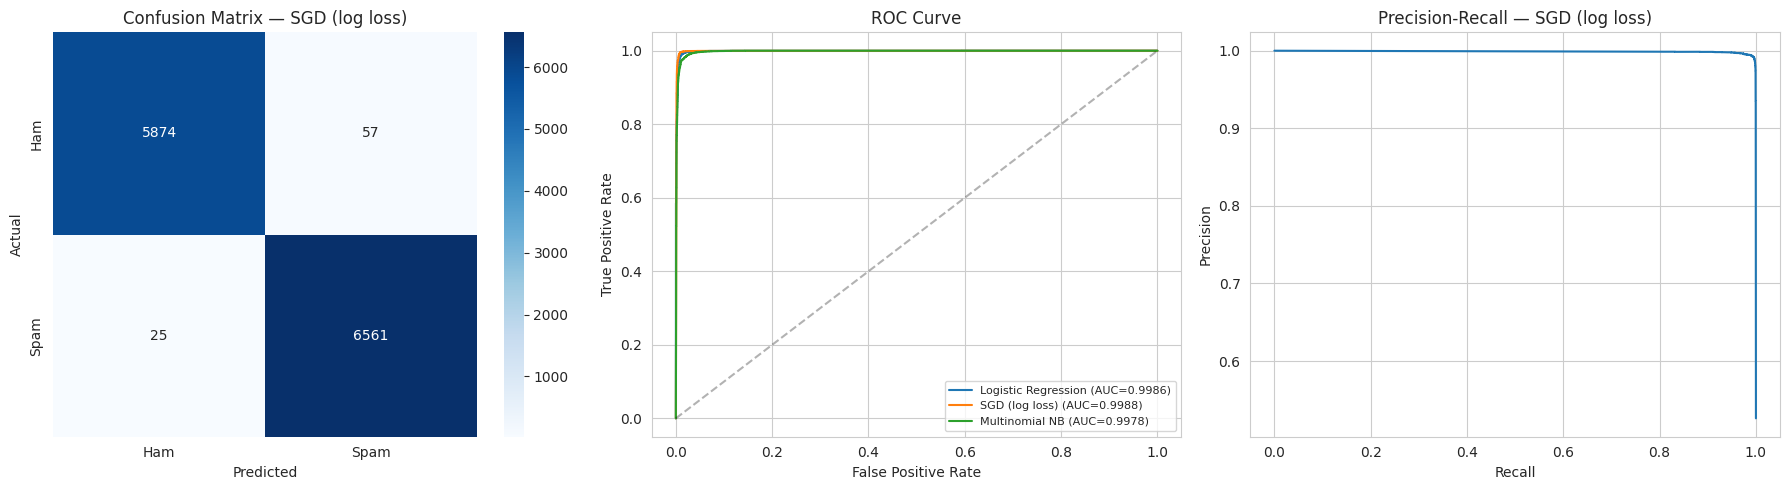

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
ax = axes[0]
cm = confusion_matrix(y_test, best["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"], ax=ax)
ax.set_title(f"Confusion Matrix — {best_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

# ROC curve (all models)
ax = axes[1]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax.plot(fpr, tpr, label=f'{name} (AUC={res["roc_auc"]:.4f})')
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_title("ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=8)

# Precision-Recall curve
ax = axes[2]
prec, rec, _ = precision_recall_curve(y_test, best["y_proba"])
ax.plot(rec, prec)
ax.set_title(f"Precision-Recall — {best_name}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

plt.tight_layout()
plt.show()

## 8. Feature Importance — What Words Matter?

Linear models (LR, SGD) assign a **weight** to each word/bigram. Large positive weights push the prediction toward spam; large negative weights push toward ham. This gives us direct interpretability — we can see exactly *why* the model flags an email.

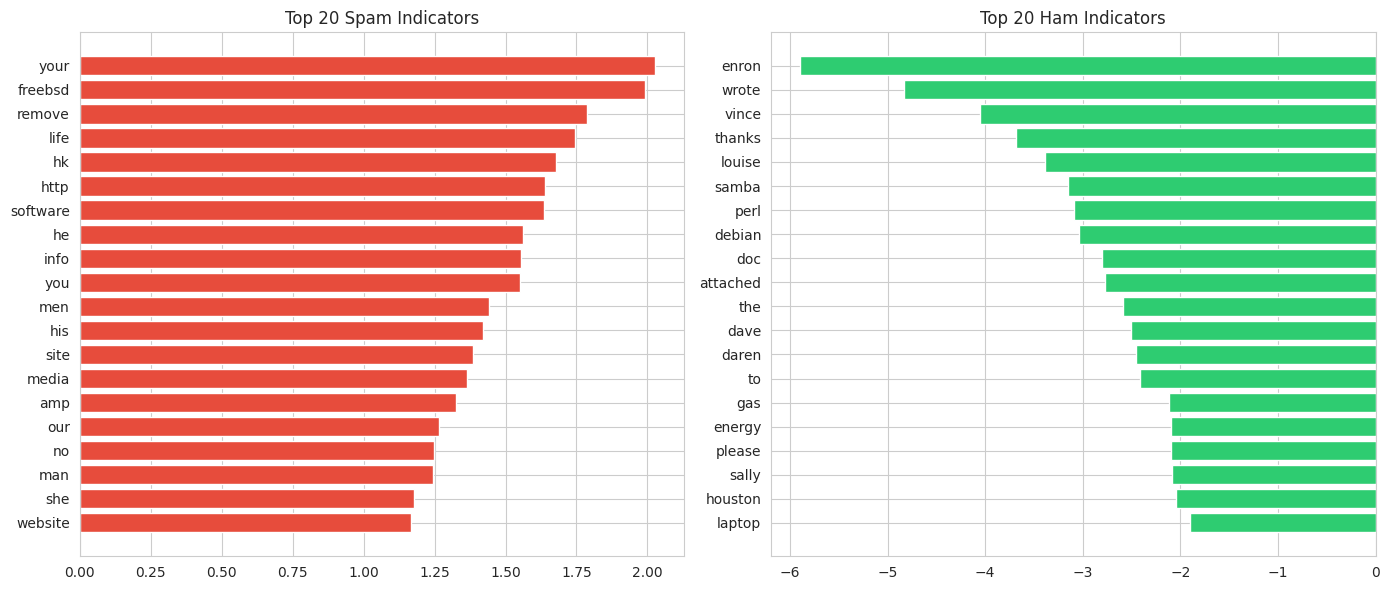

In [36]:
if hasattr(models[best_name], "coef_"):
    feature_names = np.array(tfidf.get_feature_names_out())
    coefs = models[best_name].coef_.ravel()
    top_spam_idx = coefs.argsort()[-20:][::-1]
    top_ham_idx = coefs.argsort()[:20]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].barh(feature_names[top_spam_idx][::-1], coefs[top_spam_idx][::-1], color="#e74c3c")
    axes[0].set_title("Top 20 Spam Indicators")
    axes[1].barh(feature_names[top_ham_idx][::-1], coefs[top_ham_idx][::-1], color="#2ecc71")
    axes[1].set_title("Top 20 Ham Indicators")
    plt.tight_layout()
    plt.show()
else:
    print("Best model doesn't expose coefficients (Naive Bayes uses log-probabilities instead).")

## 9. Save the Model

We package the TF-IDF vectorizer and classifier into a single **scikit-learn Pipeline** and serialize it with `joblib`. This means loading and using the model later requires just two lines of code.

In [37]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

final_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("clf", models[best_name]),
])
joblib.dump(final_pipeline, OUTPUT_DIR / "spam_detector_pipeline.joblib")
print(f"Saved → {OUTPUT_DIR / 'spam_detector_pipeline.joblib'}")

Saved → outputs/spam_detector_pipeline.joblib


## 10. Demo — Try It Out

Let's classify some example emails to see the model in action.

In [38]:
demo_texts = [
    "Congratulations! You've won a $1000 gift card. Click here to claim now!",
    "Hey, are we still meeting at 3pm for the project review?",
    "URGENT: Your account has been compromised. Verify your identity immediately.",
    "The quarterly report is attached. Let me know if you have questions.",
    "Buy cheap medications online! No prescription needed. Limited time offer!",
    "Thanks for the feedback on the PR. I'll address those comments today.",
]

for text in demo_texts:
    cleaned = clean_text(text)
    pred = final_pipeline.predict([cleaned])[0]
    proba = final_pipeline.predict_proba([cleaned])[0, 1]
    label = "SPAM" if pred == 1 else "HAM"
    print(f"[{label} {proba:6.2%}]  {text}")

[SPAM 100.00%]  Congratulations! You've won a $1000 gift card. Click here to claim now!
[HAM  0.00%]  Hey, are we still meeting at 3pm for the project review?
[SPAM 100.00%]  URGENT: Your account has been compromised. Verify your identity immediately.
[HAM  0.00%]  The quarterly report is attached. Let me know if you have questions.
[SPAM 100.00%]  Buy cheap medications online! No prescription needed. Limited time offer!
[HAM  0.00%]  Thanks for the feedback on the PR. I'll address those comments today.


## Summary

| Step | What we did | Why |
|------|------------|-----|
| EDA | Checked balance, lengths, examples | Understand the data before modeling |
| Preprocessing | Lowercased, replaced URLs/numbers, removed punctuation | Reduce noise, normalize vocabulary |
| TF-IDF | Converted text to 120K-dimensional sparse vectors | ML models need numeric input |
| Model comparison | Trained LR, SGD, Naive Bayes | Different algorithms have different strengths |
| Evaluation | Confusion matrix, ROC, PR curves, 5-fold CV | Ensure the model generalizes well |
| Interpretation | Inspected top feature weights | Understand *what* the model learned |

**Result**: The SGD classifier achieves **~99.3% accuracy** and **0.994 F1** with a TF-IDF + bigram representation — competitive with much more complex deep learning approaches, while training in under a second.